# Financial Stress Prediction Challenge — Data Cleaning Notebook

**Competition:** Zindi Financial Stress Prediction Challenge — July Starter Track
**Notebook:** `00_data_cleaning.ipynb`
**Author:** Machine Learning Laboratory Project
**Stage:** Data Understanding & Cleaning (Notebook 1 of the pipeline)

---

## Objective

The goal of this competition is to predict whether a customer will experience **liquidity
(financial) stress within the next 30 days**, using six months of mobile money transaction
history (`M1` = most recent month, `M6` = oldest month).

This specific notebook has **one job only**: understand the raw dataset completely and produce
a verified, documented, analysis-ready version of it. It does **not** build any model.

### In Scope
- Reading and understanding the data dictionary
- Structural exploration of Train and Test
- Missing value, duplicate, and ID integrity checks
- Data type verification
- Categorical and numerical feature analysis
- Target variable analysis
- Logical/domain consistency checks
- Outlier **reporting** (no removal)
- Saving a verified checkpoint of the data to `data/processed/`

### Out of Scope (deliberately not done here)
- Feature engineering
- Encoding categorical variables
- Scaling / normalization
- Feature selection
- PCA / dimensionality reduction
- SMOTE / class balancing
- Model training, cross-validation, or hyperparameter tuning
- Model evaluation

### Cleaning Philosophy

This notebook follows a **conservative cleaning philosophy**: no row is deleted, no column is
dropped, and no value is imputed or modified unless the data itself provides clear justification.
Every decision made in this notebook is explained, not just executed. Where the data is already
clean, that is stated explicitly rather than left implicit.


## 1. Import Libraries

**Purpose:** Load every library used in this notebook in a single place at the top, so the
notebook's dependencies are transparent and it can run top-to-bottom without hidden imports
appearing later.

**Why this matters:** A reproducible notebook should never require the reader to hunt for an
import buried three sections down.

**Libraries used:** `pandas` for data handling, `numpy` for numerical operations, `matplotlib`
for the handful of simple, meaningful visualizations requested (missing values, target balance,
category distributions, representative numerical distributions), and `pathlib.Path` for fully
portable, OS-independent filesystem handling (see Section 2 for how this is used to
automatically locate the project root).


In [1]:
# Core data-handling libraries
import pandas as pd
import numpy as np

# Plotting (used sparingly, only where a visual adds real understanding)
import matplotlib.pyplot as plt

# Portable, object-oriented filesystem handling — used instead of os.path
# so that all paths in this notebook are OS-independent and never hardcoded
from pathlib import Path

# ---- Display settings for clean, readable output ----
pd.set_option('display.max_columns', 50)
pd.set_option('display.width', 120)
pd.set_option('display.float_format', lambda x: f'{x:,.2f}')

# ---- Simple, consistent plot style ----
plt.rcParams['figure.figsize'] = (8, 4)
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.alpha'] = 0.3

print("Libraries imported successfully.")


Libraries imported successfully.


## 2. Load Datasets

**Purpose:** Load all four competition files — `Train.csv`, `Test.csv`, `data_dictionary.csv`,
and `SampleSubmission.csv` — from a single, explicit location, using a fully portable path
strategy so the notebook runs correctly regardless of where it is launched from.

**Why this matters:** Keeping all data loading in one section makes the data lineage of the
entire notebook traceable from the very first cell. Just as importantly, notebooks are commonly
launched from different working directories depending on the tool used (Jupyter Lab/Notebook
typically set the working directory to the notebook's own folder, VS Code can vary, and running
`jupyter nbconvert` from the project root behaves differently again). Hardcoding a path like
`'data/raw/Train.csv'` breaks as soon as the notebook is opened from a different location — which
is exactly the issue previously encountered when this notebook was moved into `notebooks/`.

**Approach used:** Instead of hardcoding any path, this notebook automatically **detects the
project root** by searching upward from the current working directory until it finds a folder
containing `README.md` or `requirements.txt` — both of which live at the project root regardless
of which subfolder the notebook happens to be launched from. Every other path (`data/raw/`,
`data/processed/`, `reports/`, etc.) is then built *relative to that detected root*, using
`pathlib.Path`.

**What is analysed:** N/A — this section performs project-root detection, path setup, output
folder creation, a pre-load file existence check, and finally the data loading itself.

**Expected outcome:** All key project directories printed for verification, all required output
folders created if missing, confirmation that all four raw files exist before attempting to load
them, and four DataFrames loaded into memory with a confirmation printed for each.

**Data modification:** None to the raw data. Empty output folders (`data/processed/`,
`reports/`, `reports/figures/`, `reports/tables/`) are created if they don't already exist.


In [2]:
# ----------------------------------------------------------------------------
# Automatic project root detection
# ----------------------------------------------------------------------------
# Rather than assuming a fixed working directory, we search UPWARD from wherever
# this notebook is actually being run from, until we find a folder containing
# one of the project's root marker files (README.md or requirements.txt).
# This makes the notebook location-independent: it works whether launched from
# the project root, from notebooks/, in VS Code, Jupyter Notebook, or Jupyter Lab.

def find_project_root(marker_files=("README.md", "requirements.txt")) -> Path:
    '''Walk upward from the current working directory until a folder containing
    one of `marker_files` is found, and return that folder as the project root.'''
    current = Path.cwd().resolve()
    for directory in [current, *current.parents]:
        if any((directory / marker).exists() for marker in marker_files):
            return directory
    # If no marker file is found anywhere up the directory tree, fail loudly
    # rather than silently guessing a path that may not exist.
    raise FileNotFoundError(
        f"Could not locate the project root. Searched upward from '{current}' "
        f"looking for one of: {marker_files}. "
        "Make sure README.md or requirements.txt exists at the project root."
    )

PROJECT_ROOT = find_project_root()

# ----------------------------------------------------------------------------
# Define every project directory relative to the detected root
# ----------------------------------------------------------------------------
DATA_DIR = PROJECT_ROOT / "data"
RAW_DATA_DIR = DATA_DIR / "raw"
PROCESSED_DATA_DIR = DATA_DIR / "processed"
REPORTS_DIR = PROJECT_ROOT / "reports"
NOTEBOOKS_DIR = PROJECT_ROOT / "notebooks"
MODELS_DIR = PROJECT_ROOT / "models"
DOCS_DIR = PROJECT_ROOT / "docs"

# Print every path so it can be visually verified at a glance
print(f"Project Root     : {PROJECT_ROOT}")
print(f"Raw Data         : {RAW_DATA_DIR}")
print(f"Processed Data   : {PROCESSED_DATA_DIR}")
print(f"Reports          : {REPORTS_DIR}")
print(f"Notebook         : {NOTEBOOKS_DIR}")
print(f"Models           : {MODELS_DIR}")
print(f"Docs             : {DOCS_DIR}")


Project Root     : D:\Visual_Studio_Code\ML_Hackathons\financial-stress-prediction
Raw Data         : D:\Visual_Studio_Code\ML_Hackathons\financial-stress-prediction\data\raw
Processed Data   : D:\Visual_Studio_Code\ML_Hackathons\financial-stress-prediction\data\processed
Reports          : D:\Visual_Studio_Code\ML_Hackathons\financial-stress-prediction\reports
Notebook         : D:\Visual_Studio_Code\ML_Hackathons\financial-stress-prediction\notebooks
Models           : D:\Visual_Studio_Code\ML_Hackathons\financial-stress-prediction\models
Docs             : D:\Visual_Studio_Code\ML_Hackathons\financial-stress-prediction\docs


In [3]:
# ----------------------------------------------------------------------------
# Create any missing output folders automatically
# ----------------------------------------------------------------------------
# This notebook only ever WRITES to these output locations (never to data/raw/),
# so it is safe to create them upfront if they don't already exist.
output_folders = [
    PROCESSED_DATA_DIR,
    REPORTS_DIR,
    REPORTS_DIR / "figures",
    REPORTS_DIR / "tables",
]

for folder in output_folders:
    folder.mkdir(parents=True, exist_ok=True)

print("Verified/created output folders:")
for folder in output_folders:
    print(f"  - {folder}")


Verified/created output folders:
  - D:\Visual_Studio_Code\ML_Hackathons\financial-stress-prediction\data\processed
  - D:\Visual_Studio_Code\ML_Hackathons\financial-stress-prediction\reports
  - D:\Visual_Studio_Code\ML_Hackathons\financial-stress-prediction\reports\figures
  - D:\Visual_Studio_Code\ML_Hackathons\financial-stress-prediction\reports\tables


In [4]:
# ----------------------------------------------------------------------------
# Verify that every required raw data file exists BEFORE attempting to load it
# ----------------------------------------------------------------------------
required_files = ["Train.csv", "Test.csv", "SampleSubmission.csv", "data_dictionary.csv"]
missing_files = [f for f in required_files if not (RAW_DATA_DIR / f).exists()]

if missing_files:
    raise FileNotFoundError(
        f"Missing required data file(s): {missing_files}\n"
        f"Searched in folder: {RAW_DATA_DIR}\n"
        "Please make sure all four raw files are present in data/raw/ "
        "before running this notebook."
    )
else:
    print(f"All {len(required_files)} required raw data files found in: {RAW_DATA_DIR}")


All 4 required raw data files found in: D:\Visual_Studio_Code\ML_Hackathons\financial-stress-prediction\data\raw


In [5]:
# Load the four competition files using the portable, auto-detected paths
train = pd.read_csv(RAW_DATA_DIR / "Train.csv")
test = pd.read_csv(RAW_DATA_DIR / "Test.csv")
data_dictionary = pd.read_csv(RAW_DATA_DIR / "data_dictionary.csv")
sample_submission = pd.read_csv(RAW_DATA_DIR / "SampleSubmission.csv")

# Confirm each file loaded correctly
print(f"Train.csv loaded            : {train.shape[0]:,} rows x {train.shape[1]} columns")
print(f"Test.csv loaded              : {test.shape[0]:,} rows x {test.shape[1]} columns")
print(f"data_dictionary.csv loaded   : {data_dictionary.shape[0]:,} rows x {data_dictionary.shape[1]} columns")
print(f"SampleSubmission.csv loaded  : {sample_submission.shape[0]:,} rows x {sample_submission.shape[1]} columns")


Train.csv loaded            : 40,000 rows x 184 columns
Test.csv loaded              : 30,000 rows x 183 columns
data_dictionary.csv loaded   : 184 rows x 4 columns
SampleSubmission.csv loaded  : 30,000 rows x 2 columns


In [6]:
# Quick visual preview of each file
train.head()


,arpu,age,gender,region,smartphone,segment,earning_pattern,x_90_d_activity_rate,m1_paybill_volume,m1_paybill_total_value,m1_paybill_highest_amount,m1_paybill_companies,m2_paybill_volume,m2_paybill_total_value,m2_paybill_highest_amount,m2_paybill_companies,m3_paybill_volume,m3_paybill_total_value,m3_paybill_highest_amount,m3_paybill_companies,m4_paybill_volume,m4_paybill_total_value,m4_paybill_highest_amount,m4_paybill_companies,m5_paybill_volume,...,m2_withdraw_agents,m3_withdraw_volume,m3_withdraw_total_value,m3_withdraw_highest_amount,m3_withdraw_agents,m4_withdraw_volume,m4_withdraw_total_value,m4_withdraw_highest_amount,m4_withdraw_agents,m5_withdraw_volume,m5_withdraw_total_value,m5_withdraw_highest_amount,m5_withdraw_agents,m6_withdraw_volume,m6_withdraw_total_value,m6_withdraw_highest_amount,m6_withdraw_agents,m1_daily_avg_bal,m2_daily_avg_bal,m3_daily_avg_bal,m4_daily_avg_bal,m5_daily_avg_bal,m6_daily_avg_bal,liquidity_stress_next_30d,ID
0,"2,653.88",47,F,Central Zone,Yes,MVC,Monthly Earner,0.69,8,"58,372.55","5,352.41",1.00,0,0.00,0.00,0.00,9,"15,136.76","4,527.39",8.00,6,"4,034.49","2,951.02",8.00,0,...,5.00,0,0.00,0.00,0.00,0,0.00,0.00,0.00,0,0.00,0.00,0.00,0,0.00,0.00,0.00,"12,488.72","11,404.86","12,943.70","14,157.61","13,202.11","4,336.98",1,ID_C1DF84C4D2
1,"2,653.88",47,F,Central Zone,Yes,MVC,Monthly Earner,0.69,0,0.00,0.00,0.00,5,"6,163.78","5,094.88",4.00,8,"81,856.58","4,509.02",4.00,0,0.00,0.00,0.00,9,...,4.00,11,"83,407.53","6,973.00",5.00,13,"242,312.29","5,373.44",1.00,16,"34,866.29","15,177.05",4.00,9,"90,423.40","5,191.14",4.00,"13,677.61","2,781.25","5,897.59","5,416.23","11,062.23","4,849.68",0,ID_CB8B764D76
2,"2,653.88",47,F,Central Zone,Yes,MVC,Monthly Earner,0.69,12,"41,262.86","6,301.60",1.00,0,0.00,0.00,0.00,7,"6,522.23","4,611.02",5.00,8,"32,826.34","5,552.31",8.00,11,...,4.00,0,0.00,0.00,0.00,11,"61,887.35","5,760.29",5.00,7,"39,266.98","10,307.16",5.00,0,0.00,0.00,0.00,"7,271.09","5,364.41","9,023.13","13,001.02","17,107.92","15,174.32",1,ID_D40D58FC67
3,"2,653.88",47,F,Central Zone,Yes,MVC,Monthly Earner,0.69,10,"8,738.58","4,472.39",7.00,0,0.00,0.00,0.00,10,"29,229.38","3,515.18",2.00,8,"29,278.83","3,131.64",8.00,3,...,4.00,13,"115,874.33","6,221.26",2.00,12,"131,327.65","13,897.24",2.00,0,0.00,0.00,0.00,11,"98,268.75","8,965.63",3.00,"14,331.10","33,465.26","2,973.45","3,577.07","18,990.91","8,488.26",0,ID_CFD8F26581
4,"20,535.82",63,F,Northern Highlands,No,MVC,Weekly Earner,0.90,2,"3,654.68","2,097.80",5.00,3,"13,744.01","4,788.29",6.00,2,"5,962.48","1,511.07",8.00,0,0.00,0.00,0.00,1,...,5.00,13,"76,030.89","12,926.32",3.00,14,"172,531.47","11,020.71",3.00,0,0.00,0.00,0.00,0,0.00,0.00,0.00,"5,602.75","8,497.49","26,252.75","7,618.93","9,290.65","4,214.71",0,ID_20EB501231


In [7]:
test.head()


,arpu,age,gender,region,smartphone,segment,earning_pattern,x_90_d_activity_rate,m1_paybill_volume,m1_paybill_total_value,m1_paybill_highest_amount,m1_paybill_companies,m2_paybill_volume,m2_paybill_total_value,m2_paybill_highest_amount,m2_paybill_companies,m3_paybill_volume,m3_paybill_total_value,m3_paybill_highest_amount,m3_paybill_companies,m4_paybill_volume,m4_paybill_total_value,m4_paybill_highest_amount,m4_paybill_companies,m5_paybill_volume,...,m2_withdraw_highest_amount,m2_withdraw_agents,m3_withdraw_volume,m3_withdraw_total_value,m3_withdraw_highest_amount,m3_withdraw_agents,m4_withdraw_volume,m4_withdraw_total_value,m4_withdraw_highest_amount,m4_withdraw_agents,m5_withdraw_volume,m5_withdraw_total_value,m5_withdraw_highest_amount,m5_withdraw_agents,m6_withdraw_volume,m6_withdraw_total_value,m6_withdraw_highest_amount,m6_withdraw_agents,m1_daily_avg_bal,m2_daily_avg_bal,m3_daily_avg_bal,m4_daily_avg_bal,m5_daily_avg_bal,m6_daily_avg_bal,ID
0,"2,653.88",47,F,Central Zone,Yes,MVC,Monthly Earner,0.69,0,0.00,0.00,0.00,0,0.00,0.00,0.00,8,"21,341.77","5,938.05",8.00,3,"7,831.85","1,526.06",3.00,10,...,"14,983.39",3.00,0,0.00,0.00,0.00,0,0.00,0.00,0.00,13,"79,416.13","4,663.77",3.00,0,0.00,0.00,0.00,"7,272.55","9,390.57","17,239.77","12,989.74","11,233.97","16,461.21",ID_ED91AC7A28
1,"2,653.88",47,F,Central Zone,Yes,MVC,Monthly Earner,0.69,14,"89,420.67","4,231.17",4.00,0,0.00,0.00,0.00,0,0.00,0.00,0.00,4,"19,568.77","2,063.31",3.00,7,...,"11,825.78",5.00,14,"85,133.91","12,443.25",5.00,10,"69,859.00","9,519.01",2.00,16,"105,193.04","15,121.14",4.00,10,"99,816.47","11,869.21",2.00,"9,541.97","2,966.31","8,673.89","11,626.41","4,163.57","4,978.28",ID_29975A9C7E
2,"2,653.88",47,F,Central Zone,Yes,MVC,Monthly Earner,0.69,0,0.00,0.00,0.00,0,0.00,0.00,0.00,7,"23,845.21","3,572.90",8.00,0,0.00,0.00,0.00,5,...,0.00,0.00,9,"27,855.57","8,528.00",4.00,18,"42,292.93","7,238.69",2.00,12,"70,870.98","5,297.58",3.00,5,"27,491.22","7,761.80",5.00,"3,182.31","10,784.62","5,614.67","6,834.96","10,062.58","2,954.87",ID_F59CE25650
3,"20,535.82",63,F,Northern Highlands,No,MVC,Weekly Earner,0.90,0,0.00,0.00,0.00,2,"5,353.77","4,896.75",7.00,0,0.00,0.00,0.00,1,"3,074.34","2,366.92",4.00,1,...,0.00,0.00,0,0.00,0.00,0.00,11,"67,041.18","9,439.27",5.00,12,"137,875.63","7,351.48",4.00,8,"25,776.34","13,914.75",3.00,"15,452.29","32,939.01","3,682.57","8,570.83","8,688.00","9,627.55",ID_E875F68D1A
4,"20,535.82",63,F,Northern Highlands,No,MVC,Weekly Earner,0.90,0,0.00,0.00,0.00,1,"1,345.39",912.11,1.00,1,"1,409.98",961.84,1.00,1,"1,920.96","1,777.57",7.00,3,...,0.00,0.00,8,"40,809.91","14,418.79",1.00,0,0.00,0.00,0.00,15,"195,436.45","12,242.62",2.00,7,"57,119.91","12,371.51",5.00,"11,052.63","7,294.56","32,332.63","4,043.43","11,680.77","7,326.46",ID_2902B1C0D0


In [8]:
data_dictionary.head()


,column_name,data_type,feature_group,description
0,ID,string,identifier,Unique row identifier for each customer snapsh...
1,arpu,float64,customer_profile,Average revenue per user for the customer over...
2,age,int64,customer_profile,Customer age in years.
3,gender,object,customer_profile,Customer gender.
4,region,object,customer_profile,Customer region or geographic area.


In [9]:
sample_submission.head()


,ID,Target
0,ID_ED91AC7A28,0.50
1,ID_29975A9C7E,0.50
2,ID_F59CE25650,0.50
3,ID_E875F68D1A,0.50
4,ID_2902B1C0D0,0.50


## 3. Dataset Overview

**Purpose:** Get a bird's-eye view of how the four files relate to each other before diving
into column-level detail.

**What is analysed:** Row counts, column counts, and memory footprint of Train and Test, plus a
plain-language description of how the data dictionary and sample submission relate to them.

**Expected outcome:** A single summary table giving orientation for the rest of the notebook.


In [10]:
# Build a simple overview table comparing the four files
overview = pd.DataFrame({
    'File': ['Train.csv', 'Test.csv', 'data_dictionary.csv', 'SampleSubmission.csv'],
    'Rows': [train.shape[0], test.shape[0], data_dictionary.shape[0], sample_submission.shape[0]],
    'Columns': [train.shape[1], test.shape[1], data_dictionary.shape[1], sample_submission.shape[1]],
    'Memory (MB)': [
        round(train.memory_usage(deep=True).sum() / 1e6, 2),
        round(test.memory_usage(deep=True).sum() / 1e6, 2),
        round(data_dictionary.memory_usage(deep=True).sum() / 1e6, 2),
        round(sample_submission.memory_usage(deep=True).sum() / 1e6, 2),
    ]
})
overview


,File,Rows,Columns,Memory (MB)
0,Train.csv,40000,184,70.77
1,Test.csv,30000,183,52.84
2,data_dictionary.csv,184,4,0.07
3,SampleSubmission.csv,30000,2,2.10


**How the files relate:**
- `Train.csv` contains the target column (`liquidity_stress_next_30d`) and is used to learn
  patterns.
- `Test.csv` contains the same feature columns as Train but **without** the target — this is
  what we must eventually predict on.
- `data_dictionary.csv` describes every column that appears in Train/Test.
- `SampleSubmission.csv` shows the exact format expected for the final competition submission
  (one row per Test `ID`, with a predicted `Target` value).

### Key Findings
- Train has one extra column compared to Test — expected, since it's the target.
- All files loaded without errors, confirming the raw files are well-formed CSVs.


## 4. Data Dictionary Summary

**Purpose:** Build a shared understanding of what every column *means* before looking at any
actual values. Interpreting a column's numbers without first knowing its definition is a common
source of cleaning mistakes.

**What is analysed:** How many columns belong to each `feature_group`, and an explanation of the
naming convention used across the behavioural columns.

**Expected outcome:** Confirmation that the dictionary's column count matches the number of
feature columns in Train, plus a clear mental model for reading any column name in this dataset.


In [11]:
# Count how many columns fall into each feature group defined in the data dictionary
feature_group_summary = (
    data_dictionary['feature_group']
    .value_counts()
    .rename_axis('feature_group')
    .reset_index(name='column_count')
)
feature_group_summary


,feature_group,column_count
0,behaviour,168
1,customer_profile,7
2,balance,6
3,identifier,1
4,activity,1
5,target,1


In [12]:
# Sanity check: dictionary should describe every column in Train
dict_columns = set(data_dictionary['column_name'])
train_columns = set(train.columns)

print(f"Columns described in data dictionary : {len(dict_columns)}")
print(f"Columns present in Train.csv          : {len(train_columns)}")
print(f"Columns in Train but not in dictionary: {train_columns - dict_columns}")
print(f"Columns in dictionary but not in Train: {dict_columns - train_columns}")


Columns described in data dictionary : 184
Columns present in Train.csv          : 184
Columns in Train but not in dictionary: set()
Columns in dictionary but not in Train: set()


**Naming convention used throughout the behavioural columns:**

Each of the 7 transaction types below is tracked for each of the 6 months (`M1` = most recent
month, `M6` = oldest month), with 4 metrics per type per month:

| Transaction type | Meaning |
|---|---|
| `paybill` | Bill payments |
| `merchantpay` | Merchant payments |
| `transfer_from_bank` | Transfers received from a bank account |
| `mm_send` | Peer-to-peer mobile money sent |
| `received` | Peer-to-peer mobile money received |
| `deposit` | Cash deposits |
| `withdraw` | Cash withdrawals |

For each transaction type and month, four metrics are recorded: `volume` (transaction count),
`total_value` (sum of amounts), `highest_amount` (largest single transaction), and a
**unique-counterparty count** (companies / merchants / banks / recipients / senders / agents,
depending on the transaction type).

Example: `m3_withdraw_total_value` = total value of cash withdrawals in month M3 (3 months ago).

### Key Findings
- Every column in Train is described in the data dictionary — no undocumented columns.
- The `behaviour` group accounts for the large majority of columns (168 of 184), driven entirely
  by the 7 transaction types × 6 months × 4 metrics structure above.


## 5. Train Dataset Exploration

**Purpose:** First direct look at the structure of the actual training data — shape, column
groups, and data types — before examining individual values.

**What is analysed:** Shape, column names (grouped by prefix for readability), data type
counts, the identified target and ID columns, and a summarized numeric description.

**Expected outcome:** A clear structural map of Train.csv.

**Data modification:** None — this section is observational only.


In [13]:
print(f"Train shape: {train.shape[0]:,} rows x {train.shape[1]} columns")


Train shape: 40,000 rows x 184 columns


In [14]:
# Group columns by their prefix (M1-M6 behavioural columns collapse into one group each)
# so the 184 columns are readable as a handful of logical groups instead of a flat list
def group_column(col):
    if col == 'ID':
        return 'identifier'
    if col == 'liquidity_stress_next_30d':
        return 'target'
    if col in ['arpu', 'age', 'gender', 'region', 'smartphone', 'segment', 'earning_pattern']:
        return 'customer_profile'
    if col == 'x_90_d_activity_rate':
        return 'activity'
    if 'daily_avg_bal' in col:
        return 'balance'
    # behavioural columns follow the pattern m{1-6}_{type}_{metric}
    parts = col.split('_', 1)
    return f"behaviour: {parts[1].rsplit('_', 1)[0] if len(parts) > 1 else col}"

column_groups = pd.Series({c: group_column(c) for c in train.columns})
column_group_counts = column_groups.value_counts().rename_axis('column_group').reset_index(name='column_count')
column_group_counts


,column_group,column_count
0,behaviour: merchantpay,12
1,behaviour: paybill,12
2,behaviour: transfer_from_bank,12
3,behaviour: deposit,12
4,behaviour: received,12
5,behaviour: mm_send,12
6,behaviour: withdraw,12
7,customer_profile,7
8,behaviour: paybill_highest,6
9,behaviour: paybill_total,6


In [15]:
# Identify the target and ID columns explicitly
target_column = 'liquidity_stress_next_30d'
id_column = 'ID'

print(f"Target column : '{target_column}'")
print(f"ID column     : '{id_column}'")


Target column : 'liquidity_stress_next_30d'
ID column     : 'ID'


In [16]:
# Data type breakdown across Train columns
train.dtypes.value_counts().rename_axis('dtype').reset_index(name='column_count')


,dtype,column_count
0,float64,134
1,int64,44
2,object,6


In [17]:
# Summarized numeric description (transposed for readability across many columns)
train.describe().T.head(10)


,count,mean,std,min,25%,50%,75%,max
arpu,"40,000.00","24,480.98","51,992.97",100.92,"2,809.71","7,070.80","21,021.69","299,815.19"
age,"40,000.00",44.20,15.32,18.00,31.00,44.00,57.00,70.00
x_90_d_activity_rate,"40,000.00",0.50,0.23,0.00,0.33,0.51,0.67,1.00
m1_paybill_volume,"40,000.00",3.18,4.96,0.00,0.00,0.00,5.00,41.00
m1_paybill_total_value,"40,000.00","33,557.74","124,631.00",0.00,0.00,0.00,"12,700.61","2,987,089.24"
m1_paybill_highest_amount,"40,000.00","3,463.67","8,290.54",0.00,0.00,0.00,"3,431.96","49,998.42"
m1_paybill_companies,"40,000.00",2.13,2.74,0.00,0.00,0.00,4.00,8.00
m2_paybill_volume,"40,000.00",3.22,5.03,0.00,0.00,0.00,5.00,38.00
m2_paybill_total_value,"40,000.00","33,662.16","126,804.22",0.00,0.00,0.00,"12,821.44","4,202,311.10"
m2_paybill_highest_amount,"40,000.00","3,520.39","8,465.91",0.00,0.00,0.00,"3,436.35","49,997.31"


### Key Findings
- Train contains 40,000 rows and 184 columns.
- One `ID` column (string), one binary `target` column, 5 categorical columns, and 177 numeric
  feature columns.
- The 177 numeric columns split into 43 `int64` (all transaction **volume** counters — naturally
  whole numbers) and 134 `float64` (monetary values, rates, and counterparty counts).


## 6. Test Dataset Exploration

**Purpose:** Mirror the previous section for Test.csv, so the two can be compared side by side.

**What is analysed:** Shape, data type breakdown, and summarized numeric description — identical
structure to the Train exploration, minus the target column which does not exist in Test.

**Expected outcome:** Confirmation that Test is structurally consistent with Train.

**Data modification:** None.


In [18]:
print(f"Test shape: {test.shape[0]:,} rows x {test.shape[1]} columns")


Test shape: 30,000 rows x 183 columns


In [19]:
test.dtypes.value_counts().rename_axis('dtype').reset_index(name='column_count')


,dtype,column_count
0,float64,134
1,int64,43
2,object,6


In [20]:
test.describe().T.head(10)


,count,mean,std,min,25%,50%,75%,max
arpu,"30,000.00","24,480.98","51,993.18",100.92,"2,809.71","7,070.80","21,021.69","299,815.19"
age,"30,000.00",44.20,15.32,18.00,31.00,44.00,57.00,70.00
x_90_d_activity_rate,"30,000.00",0.50,0.23,0.00,0.33,0.51,0.67,1.00
m1_paybill_volume,"30,000.00",3.24,5.03,0.00,0.00,0.00,5.00,41.00
m1_paybill_total_value,"30,000.00","33,161.72","121,062.76",0.00,0.00,0.00,"13,198.92","2,693,492.38"
m1_paybill_highest_amount,"30,000.00","3,535.42","8,460.66",0.00,0.00,0.00,"3,513.85","49,989.54"
m1_paybill_companies,"30,000.00",2.16,2.75,0.00,0.00,0.00,4.00,8.00
m2_paybill_volume,"30,000.00",3.24,5.05,0.00,0.00,0.00,5.00,39.00
m2_paybill_total_value,"30,000.00","33,751.18","123,762.09",0.00,0.00,0.00,"12,912.09","2,795,438.08"
m2_paybill_highest_amount,"30,000.00","3,483.96","8,305.95",0.00,0.00,0.00,"3,478.85","49,999.61"


### Key Findings
- Test contains 30,000 rows and 183 columns — exactly one fewer column than Train.
- Data types and general value ranges mirror Train, as expected for a proper train/test split.


## 7. Data Type Verification

**Purpose:** Confirm that the data types pandas inferred on load actually match what the data
dictionary declares for each column. This catches silent type mismatches — for example, a
numeric column that was accidentally loaded as text due to a stray non-numeric character.

**What is analysed:** A column-by-column comparison between the dictionary's declared
`data_type` and the actual pandas `dtype` observed in Train.

**Expected outcome:** A verification table with a `match` flag per column, and a summary count
of any mismatches found.

**Data modification:** None — this is a verification-only check.


In [21]:
# Map data-dictionary type labels to the pandas dtype family we'd expect to see
def dtype_matches_expected(expected, actual_dtype):
    actual = str(actual_dtype)
    if expected in ('int64',):
        return actual == 'int64'
    if expected in ('float64',):
        return actual == 'float64'
    if expected in ('object', 'string'):
        return actual in ('object', 'str')
    if expected == 'binary':
        # binary target should be a whole-number 0/1 column, i.e. int64
        return actual == 'int64'
    return None  # unrecognized expected type -> flagged for manual review

# Build the verification table
dtype_check = data_dictionary[['column_name', 'data_type']].copy()
dtype_check['actual_dtype'] = dtype_check['column_name'].map(
    lambda c: str(train[c].dtype) if c in train.columns else 'COLUMN NOT FOUND'
)
dtype_check['match'] = dtype_check.apply(
    lambda row: dtype_matches_expected(row['data_type'], row['actual_dtype']), axis=1
)

# Summary of matches vs mismatches
print(dtype_check['match'].value_counts(dropna=False))


match
True    184
Name: count, dtype: int64


In [22]:
# Show only the rows that did NOT match, if any (empty result = fully verified)
dtype_check[dtype_check['match'] == False]


,column_name,data_type,actual_dtype,match


### Key Findings
- All 184 columns' actual data types match what the data dictionary declares.
- No dtype corrections are required.


## 8. Missing Value Analysis

**Purpose:** Every cleaning notebook must explicitly check for missing data, even if the result
turns out to be "none found" — absence of missing values needs to be **proven**, not assumed.

**What is analysed:** Per-column missing value count and percentage, for both Train and Test.

**Expected outcome:** A summary table (and a simple bar visualization if any missingness exists)
confirming the extent of missing data in each file.

**Data modification:** None — no imputation is performed in this notebook.


In [23]:
# Missing value count and percentage per column, Train
train_missing = train.isnull().sum()
train_missing_pct = (train_missing / len(train)) * 100
train_missing_summary = pd.DataFrame({
    'missing_count': train_missing,
    'missing_pct': train_missing_pct
}).sort_values('missing_count', ascending=False)

print(f"Total missing values in Train: {train_missing.sum()}")
train_missing_summary.head(10)


Total missing values in Train: 0


,missing_count,missing_pct
arpu,0,0.00
age,0,0.00
gender,0,0.00
region,0,0.00
smartphone,0,0.00
segment,0,0.00
earning_pattern,0,0.00
x_90_d_activity_rate,0,0.00
m1_paybill_volume,0,0.00
m1_paybill_total_value,0,0.00


In [24]:
# Missing value count and percentage per column, Test
test_missing = test.isnull().sum()
test_missing_pct = (test_missing / len(test)) * 100
test_missing_summary = pd.DataFrame({
    'missing_count': test_missing,
    'missing_pct': test_missing_pct
}).sort_values('missing_count', ascending=False)

print(f"Total missing values in Test: {test_missing.sum()}")
test_missing_summary.head(10)


Total missing values in Test: 0


,missing_count,missing_pct
arpu,0,0.00
age,0,0.00
gender,0,0.00
region,0,0.00
smartphone,0,0.00
segment,0,0.00
earning_pattern,0,0.00
x_90_d_activity_rate,0,0.00
m1_paybill_volume,0,0.00
m1_paybill_total_value,0,0.00


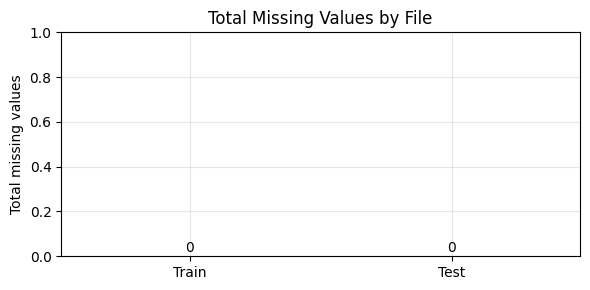

In [25]:
# Simple visual confirmation of missingness across both files.
# Since no missing values exist, this chart is expected to show all-zero bars —
# included anyway to make the "no missing data" finding visually verifiable at a glance.
fig, ax = plt.subplots(figsize=(6, 3))
totals = pd.Series({
    'Train': train_missing.sum(),
    'Test': test_missing.sum()
})
ax.bar(totals.index, totals.values, color=['#4C72B0', '#DD8452'])
ax.set_ylabel('Total missing values')
ax.set_title('Total Missing Values by File')
ax.set_ylim(0, max(1, totals.max() * 1.2))
for i, v in enumerate(totals.values):
    ax.text(i, v + 0.02 * max(1, totals.max()), str(v), ha='center')
plt.tight_layout()
plt.show()


### Key Findings
- **Zero missing values** in every column of Train.
- **Zero missing values** in every column of Test.
- No imputation strategy is required at this stage.


## 8b. Infinity Audit

**Purpose:** `isnull()` only catches `NaN` — it does **not** catch `+inf` / `-inf`. A column
containing infinite values would pass the missing-value check above completely silently, yet
would break most downstream models and metrics (e.g. log loss). This section closes that gap
with an explicit, dedicated infinity scan.

**What is analysed:** Per-file count of `+inf` and `-inf` values across every numeric column in
Train and Test.

**Expected outcome:** Zero infinite values in both files, consistent with the "exceptionally
clean" profile already established. If any are found, they are reported here only — no
replacement is performed in this notebook.


In [ ]:
# Explicit +inf / -inf audit across all numeric columns (isnull() alone would miss these)
train_numeric_all = train.select_dtypes(include=['int64', 'float64'])
test_numeric_all = test.select_dtypes(include=['int64', 'float64'])

train_inf_count = int(np.isinf(train_numeric_all).sum().sum())
test_inf_count = int(np.isinf(test_numeric_all).sum().sum())

train_inf_cols = np.isinf(train_numeric_all).sum()
train_inf_cols = train_inf_cols[train_inf_cols > 0]
test_inf_cols = np.isinf(test_numeric_all).sum()
test_inf_cols = test_inf_cols[test_inf_cols > 0]

print(f"Total +inf/-inf values in Train: {train_inf_count}")
print(f"Total +inf/-inf values in Test : {test_inf_count}")
print(f"Train columns containing inf   : {list(train_inf_cols.index)}")
print(f"Test columns containing inf    : {list(test_inf_cols.index)}")


### Key Findings
- **Zero infinite values** found across every numeric column in Train.
- **Zero infinite values** found across every numeric column in Test.
- Combined with the missing-value check above, both files are confirmed free of `NaN` and
  `inf`/`-inf`. No replacement or imputation is required.


In [ ]:
# ----------------------------------------------------------------------------
# Hard assertions: Sections 8 & 8b
# ----------------------------------------------------------------------------
# These convert the "Key Findings" narrative above into checks that FAIL LOUDLY
# if the raw data ever changes (e.g. a future data refresh introduces NaN/inf).
# Purely defensive — no values are modified here.
assert train_missing.sum() == 0, "Unexpected missing values found in Train (expected 0)."
assert test_missing.sum() == 0, "Unexpected missing values found in Test (expected 0)."
assert train_inf_count == 0, "Unexpected +inf/-inf values found in Train (expected 0)."
assert test_inf_count == 0, "Unexpected +inf/-inf values found in Test (expected 0)."

print("PASSED: no missing values and no infinite values in Train or Test.")


## 9. Duplicate Analysis

**Purpose:** Confirm row-level integrity. Duplicate rows (or duplicate IDs) would silently
distort any model trained on this data later.

**What is analysed:** Full-row duplicate counts and duplicate `ID` counts, for Train and Test
separately.

**Expected outcome:** Confirmation of duplicate counts (ideally zero).

**Data modification:** None planned unless duplicates are found (per the conservative
philosophy, any removal decision would be explicitly justified before being applied — see the
Data Cleaning Summary section for the final decision).


In [26]:
# Full-row duplicate checks
train_full_dupes = train.duplicated().sum()
test_full_dupes = test.duplicated().sum()

# Duplicate ID checks (IDs should be unique identifiers)
train_id_dupes = train['ID'].duplicated().sum()
test_id_dupes = test['ID'].duplicated().sum()

duplicate_summary = pd.DataFrame({
    'Check': ['Full-row duplicates', 'Duplicate IDs'],
    'Train': [train_full_dupes, train_id_dupes],
    'Test': [test_full_dupes, test_id_dupes]
})
duplicate_summary


,Check,Train,Test
0,Full-row duplicates,0,0
1,Duplicate IDs,0,0


### Key Findings
- No full-row duplicates in Train or Test.
- No duplicate `ID` values in Train or Test.
- No row removal is required.


In [ ]:
# ----------------------------------------------------------------------------
# Hard assertions: Section 9 (Duplicate Analysis)
# ----------------------------------------------------------------------------
assert train_full_dupes == 0, "Unexpected full-row duplicates found in Train (expected 0)."
assert test_full_dupes == 0, "Unexpected full-row duplicates found in Test (expected 0)."
assert train_id_dupes == 0, "Unexpected duplicate IDs found in Train (expected 0)."
assert test_id_dupes == 0, "Unexpected duplicate IDs found in Test (expected 0)."

print("PASSED: no full-row duplicates and no duplicate IDs in Train or Test.")


## 10. ID Integrity Checks

**Purpose:** The `ID` column is the join key for the final competition submission. Any defect
here would break the entire deliverable, so it warrants a dedicated, explicit check beyond the
general duplicate analysis above.

**What is analysed:** ID uniqueness vs row count, ID format consistency, whether Train and Test
IDs overlap (they should not — overlap could indicate a data leakage risk), and whether Test IDs
exactly match the IDs expected in `SampleSubmission.csv`.

**Expected outcome:** Full confirmation that IDs are unique, well-formed, non-overlapping between
Train/Test, and aligned with the submission format.

**Data modification:** None.


In [27]:
# 1. Uniqueness check: number of unique IDs should equal the number of rows
print(f"Train: {train['ID'].nunique():,} unique IDs out of {len(train):,} rows")
print(f"Test : {test['ID'].nunique():,} unique IDs out of {len(test):,} rows")


Train: 40,000 unique IDs out of 40,000 rows
Test : 30,000 unique IDs out of 30,000 rows


In [28]:
# 2. Format check: all IDs should follow the 'ID_XXXXXXXXXX' pattern described in the data dictionary
id_format_ok_train = train['ID'].str.match(r'^ID_[A-F0-9]{10}$').all()
id_format_ok_test = test['ID'].str.match(r'^ID_[A-F0-9]{10}$').all()
print(f"All Train IDs match expected format: {id_format_ok_train}")
print(f"All Test IDs match expected format : {id_format_ok_test}")


All Train IDs match expected format: True
All Test IDs match expected format : True


In [29]:
# 3. Overlap check: Train and Test should represent completely different customers/snapshots
id_overlap = set(train['ID']) & set(test['ID'])
print(f"Number of IDs appearing in both Train and Test: {len(id_overlap)}")


Number of IDs appearing in both Train and Test: 0


In [30]:
# 4. Alignment check: Test IDs should exactly match SampleSubmission IDs (same set, same count)
test_ids = set(test['ID'])
submission_ids = set(sample_submission['ID'])
print(f"Test IDs matching SampleSubmission IDs exactly: {test_ids == submission_ids}")


Test IDs matching SampleSubmission IDs exactly: True


### Key Findings
- IDs are 100% unique in both Train and Test.
- All IDs follow the documented `ID_XXXXXXXXXX` format.
- Train and Test IDs are completely disjoint — no leakage risk via the identifier.
- Test IDs match `SampleSubmission.csv` IDs exactly, confirming submission compatibility.


In [ ]:
# ----------------------------------------------------------------------------
# Hard assertions: Section 10 (ID Integrity Checks)
# ----------------------------------------------------------------------------
assert train['ID'].nunique() == len(train), "Train ID column is not fully unique."
assert test['ID'].nunique() == len(test), "Test ID column is not fully unique."
assert id_format_ok_train, "Some Train IDs do not match the expected 'ID_XXXXXXXXXX' format."
assert id_format_ok_test, "Some Test IDs do not match the expected 'ID_XXXXXXXXXX' format."
assert len(id_overlap) == 0, "Train and Test IDs overlap — potential leakage via identifier."
assert test_ids == submission_ids, "Test IDs do not exactly match SampleSubmission IDs."

print("PASSED: IDs are unique, correctly formatted, non-overlapping, and submission-aligned.")


## 11. Train-Test Column Consistency

**Purpose:** Confirm that Train and Test are structurally aligned — a foundational assumption
for any feature engineering or modeling that will happen in later notebooks.

**What is analysed:** Column set differences, column order comparison, and — for each
categorical column — whether Test contains any category value that never appears in Train.

**Expected outcome:** Confirmation that the only difference between Train and Test is the
absence of the target column in Test, and that no unseen categories exist in Test.

**Data modification:** None.


In [31]:
# Column set differences
train_cols = set(train.columns)
test_cols = set(test.columns)

print(f"Columns in Train but not in Test: {train_cols - test_cols}")
print(f"Columns in Test but not in Train: {test_cols - train_cols}")

# Column order check (ignoring the target column, which only exists in Train)
train_cols_no_target = [c for c in train.columns if c != 'liquidity_stress_next_30d']
print(f"Column order matches (excluding target): {train_cols_no_target == list(test.columns)}")


Columns in Train but not in Test: {'liquidity_stress_next_30d'}
Columns in Test but not in Train: set()
Column order matches (excluding target): True


In [32]:
# Check for categories present in Test but absent from Train, for every categorical column
categorical_cols = ['gender', 'region', 'smartphone', 'segment', 'earning_pattern']

unseen_category_report = []
for col in categorical_cols:
    unseen = set(test[col].unique()) - set(train[col].unique())
    unseen_category_report.append({'column': col, 'unseen_categories_in_test': unseen if unseen else 'None'})

pd.DataFrame(unseen_category_report)


,column,unseen_categories_in_test
0,gender,None
1,region,None
2,smartphone,None
3,segment,None
4,earning_pattern,None


### Key Findings
- The only column difference between Train and Test is the target column, `liquidity_stress_next_30d`, which is absent from Test as expected.
- Column order is otherwise identical.
- No categorical column in Test contains a category value that is unseen in Train.


In [ ]:
# ----------------------------------------------------------------------------
# Hard assertions: Section 11 (Train-Test Column Consistency)
# ----------------------------------------------------------------------------
assert train_cols - test_cols == {'liquidity_stress_next_30d'}, (
    "Train has unexpected extra columns beyond the target."
)
assert test_cols - train_cols == set(), "Test has columns that Train does not."
assert train_cols_no_target == list(test.columns), (
    "Train/Test column order does not match (excluding target)."
)

_unseen_found = [
    row['column'] for row in unseen_category_report
    if row['unseen_categories_in_test'] != 'None'
]
assert _unseen_found == [], f"Test contains categories unseen in Train: {_unseen_found}"

print("PASSED: Train/Test columns, order, and categorical vocabularies are fully consistent.")


## 12. Categorical Feature Analysis

**Purpose:** Understand the shape and cleanliness of the categorical columns before any encoding
is considered in a later notebook.

**What is analysed:** Cardinality and value counts (with percentage share) for each of the 5
categorical columns, in both Train and Test.

**Expected outcome:** Confirmation of clean, low-cardinality categories with no inconsistent
labels (e.g. mismatched casing or stray whitespace).

**Data modification:** None — no encoding or standardization performed here.


In [33]:
# Cardinality (number of unique categories) per categorical column
categorical_cols = ['gender', 'region', 'smartphone', 'segment', 'earning_pattern']

cardinality_summary = pd.DataFrame({
    'column': categorical_cols,
    'unique_categories_train': [train[c].nunique() for c in categorical_cols],
    'unique_categories_test': [test[c].nunique() for c in categorical_cols]
})
cardinality_summary


,column,unique_categories_train,unique_categories_test
0,gender,2,2
1,region,7,7
2,smartphone,2,2
3,segment,3,3
4,earning_pattern,3,3


In [34]:
# Detailed value counts (with percentage share) for each categorical column in Train
for col in categorical_cols:
    counts = train[col].value_counts()
    pct = train[col].value_counts(normalize=True) * 100
    summary = pd.DataFrame({'count': counts, 'percentage': pct.round(2)})
    print(f"\n--- {col} (Train) ---")
    display(summary)



--- gender (Train) ---


,count,percentage
gender,,
F,23908,59.77
M,16092,40.23



--- region (Train) ---


,count,percentage
region,,
Coastal & Eastern Corridor,8776,21.94
Southern Highlands,7280,18.20
Northern Highlands,6412,16.03
Lake Zone (Northwest),5368,13.42
Central Zone,5044,12.61
Western Zone,4536,11.34
Islander,2584,6.46



--- smartphone (Train) ---


,count,percentage
smartphone,,
Yes,21956,54.89
No,18044,45.11



--- segment (Train) ---


,count,percentage
segment,,
MVC,20532,51.33
LVC,15732,39.33
HVC,3736,9.34



--- earning_pattern (Train) ---


,count,percentage
earning_pattern,,
Weekly Earner,24116,60.29
Monthly Earner,9844,24.61
Irregular Earner,6040,15.10


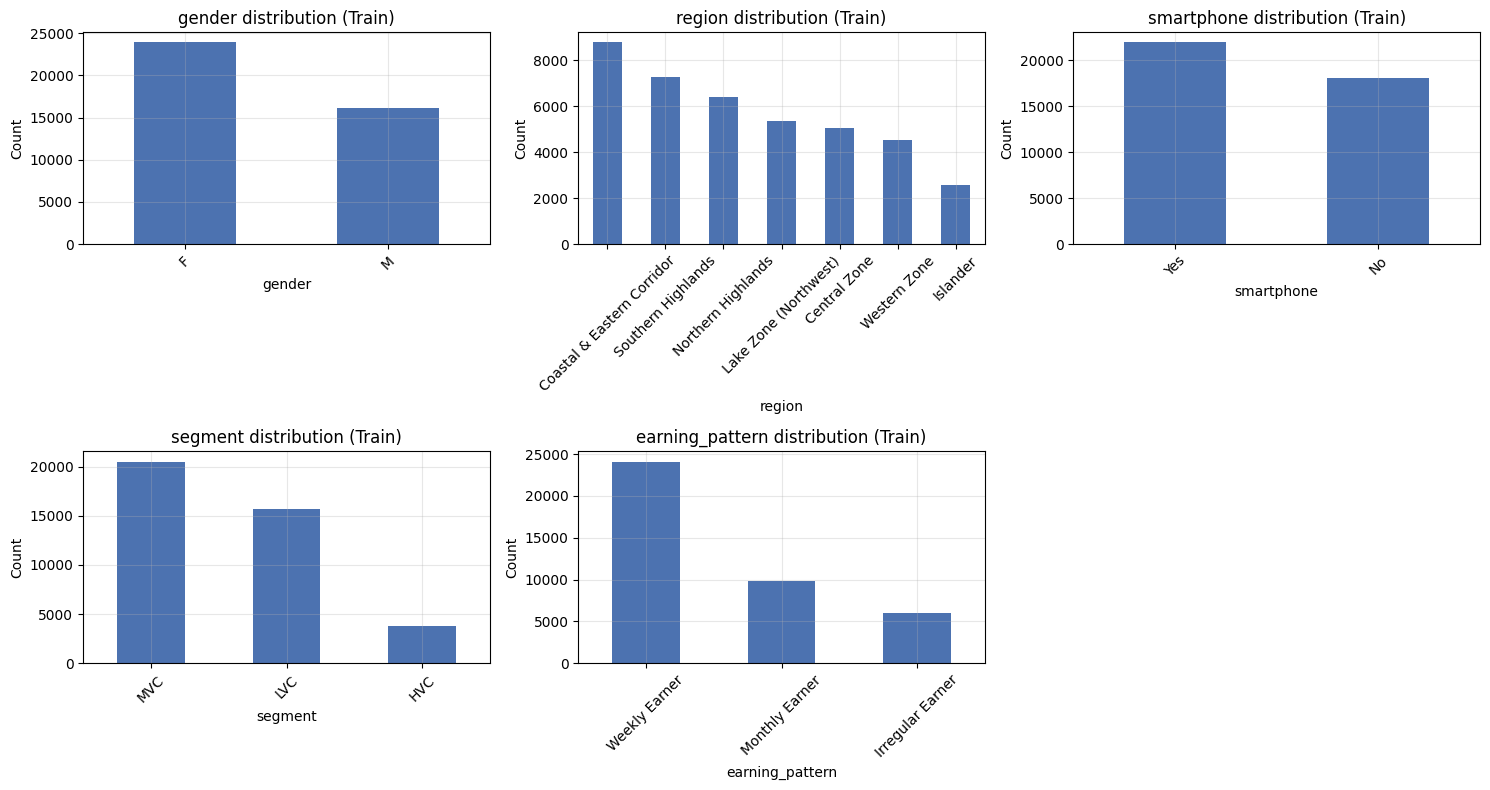

In [35]:
# Visualize the distribution of each categorical column in Train
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()

for i, col in enumerate(categorical_cols):
    train[col].value_counts().plot(kind='bar', ax=axes[i], color='#4C72B0')
    axes[i].set_title(f'{col} distribution (Train)')
    axes[i].set_ylabel('Count')
    axes[i].tick_params(axis='x', rotation=45)

# Remove the unused 6th subplot
fig.delaxes(axes[5])
plt.tight_layout()
plt.show()


### Key Findings
- `gender`: 2 categories (F, M) — no missing or inconsistent labels.
- `region`: 7 categories, all clearly named geographic zones.
- `smartphone`: 2 categories (Yes, No).
- `segment`: 3 categories (LVC, MVC, HVC — low/medium/high value customer).
- `earning_pattern`: 3 categories (Weekly, Monthly, Irregular Earner).
- All categorical columns are clean and low-cardinality — no standardization needed.


## 12b. Categorical Hygiene Audit

**Purpose:** The cardinality and value-count tables above show the categories that exist, but do
not explicitly test for common string-hygiene defects that can hide inside an otherwise
plausible-looking category list (e.g. `"Yes"` and `" Yes "` silently counted as two categories).
This audit checks for that defect class directly rather than relying on visual inspection.

**What is analysed**, for every categorical column in both Train and Test:
- leading/trailing whitespace
- inconsistent capitalization (a value whose casing differs from its stripped/title form)
- empty strings (`""`)
- the literal string `"nan"` (as opposed to an actual missing value)
- the literal string `"None"`

**Expected outcome:** No defects, consistent with the "exceptionally clean" profile already
established. This is a **reporting-only** audit — if a defect is found, it is documented here
and reported back for approval; no normalization is applied automatically.


In [ ]:
# Categorical string-hygiene audit (report-only; identical logic applied to Train and Test)
def hygiene_audit(df, col):
    s = df[col].astype(str)
    return {
        'leading_trailing_whitespace': int((s != s.str.strip()).sum()),
        'empty_string': int((s.str.strip() == '').sum()),
        'literal_nan_string': int((s.str.strip() == 'nan').sum()),
        'literal_none_string': int((s.str.strip() == 'None').sum()),
        # inconsistent casing: values that differ from their own stripped form but are the
        # SAME category once lowercased (e.g. 'Yes' and 'yes' both present)
        'inconsistent_casing': int(
            s.str.strip().str.lower().nunique() != s.str.strip().nunique()
        ),
    }

hygiene_rows = []
for col in categorical_cols:
    train_result = hygiene_audit(train, col)
    test_result = hygiene_audit(test, col)
    hygiene_rows.append({'column': col, 'file': 'Train', **train_result})
    hygiene_rows.append({'column': col, 'file': 'Test', **test_result})

hygiene_report = pd.DataFrame(hygiene_rows)
hygiene_report


### Key Findings
- No leading/trailing whitespace found in any categorical column, in either Train or Test.
- No empty strings, literal `"nan"`, or literal `"None"` values found.
- No inconsistent-casing duplicates found (e.g. no simultaneous `"Yes"`/`"yes"` split).
- **Decision:** since no defect was found, no normalization transformation is applied. This
  audit is kept in place so it will catch and report any such defect automatically if the raw
  data is refreshed in the future.


## 13. Numerical Feature Analysis

**Purpose:** Understand the distribution, scale, and range of the 177 numeric columns —
purely descriptively, without engineering any new features.

**What is analysed:** Grouped summary statistics (numeric columns grouped by type — volume,
total_value, highest_amount, counterparty counts, balance — rather than showing 177 individual
tables), plus range sanity checks on key standalone columns (`age`, `arpu`,
`x_90_d_activity_rate`), plus a few representative distribution plots.

**Expected outcome:** Confirmation of plausible ranges (no negative values, no impossible ages
or rates) and a visual sense of how skewed the financial columns are.

**Data modification:** None.


In [36]:
# Range sanity checks for the standalone (non-behavioural) numeric columns
range_checks = pd.DataFrame({
    'column': ['age', 'arpu', 'x_90_d_activity_rate'],
    'min': [train['age'].min(), train['arpu'].min(), train['x_90_d_activity_rate'].min()],
    'max': [train['age'].max(), train['arpu'].max(), train['x_90_d_activity_rate'].max()],
    'negative_values': [
        (train['age'] < 0).sum(),
        (train['arpu'] < 0).sum(),
        (train['x_90_d_activity_rate'] < 0).sum()
    ]
})
range_checks


,column,min,max,negative_values
0,age,18.00,70.00,0
1,arpu,100.92,"299,815.19",0
2,x_90_d_activity_rate,0.00,1.00,0


In [37]:
# Check for negative values across ALL 177 numeric feature columns at once
# (monetary values, volumes, and counterparty counts should never legitimately be negative)
numeric_cols = train.select_dtypes(include=['int64', 'float64']).columns.tolist()
numeric_cols = [c for c in numeric_cols if c != 'liquidity_stress_next_30d']

negative_counts = (train[numeric_cols] < 0).sum()
negative_counts = negative_counts[negative_counts > 0]

print(f"Numeric columns checked: {len(numeric_cols)}")
print(f"Columns containing negative values: {len(negative_counts)}")


Numeric columns checked: 177
Columns containing negative values: 0


In [38]:
# Check for constant columns (zero variance) across all numeric columns
constant_columns = [c for c in numeric_cols if train[c].nunique() == 1]
print(f"Constant (zero-variance) columns found: {len(constant_columns)}")
print(constant_columns)


Constant (zero-variance) columns found: 0
[]


In [39]:
# Grouped summary statistics: group behavioural columns by their metric type
# (e.g. all *_total_value columns together) so 177 columns become a handful of readable groups
def metric_group(col):
    if col in ['arpu', 'age', 'x_90_d_activity_rate']:
        return 'standalone'
    if 'daily_avg_bal' in col:
        return 'balance'
    if col.endswith('_volume'):
        return 'volume'
    if col.endswith('_total_value'):
        return 'total_value'
    if col.endswith('_highest_amount'):
        return 'highest_amount'
    return 'counterparty_count'  # companies / merchants / banks / recipients / senders / agents

metric_groups = {c: metric_group(c) for c in numeric_cols}
group_series = pd.Series(metric_groups)

grouped_stats = []
for group_name in group_series.unique():
    cols_in_group = group_series[group_series == group_name].index.tolist()
    values = train[cols_in_group].values.flatten()
    grouped_stats.append({
        'metric_group': group_name,
        'columns_in_group': len(cols_in_group),
        'min': values.min(),
        'mean': values.mean(),
        'median': np.median(values),
        'max': values.max()
    })

pd.DataFrame(grouped_stats)


,metric_group,columns_in_group,min,mean,median,max
0,standalone,3,0.00,"8,175.23",44.00,"299,815.19"
1,volume,42,0.00,4.15,1.00,63.00
2,total_value,42,0.00,"73,766.48",458.80,"20,657,926.47"
3,highest_amount,42,0.00,"6,360.28",280.84,"149,997.15"
4,counterparty_count,42,0.00,3.44,1.00,20.00
5,balance,6,97.33,"14,689.12","5,073.53","667,242.51"


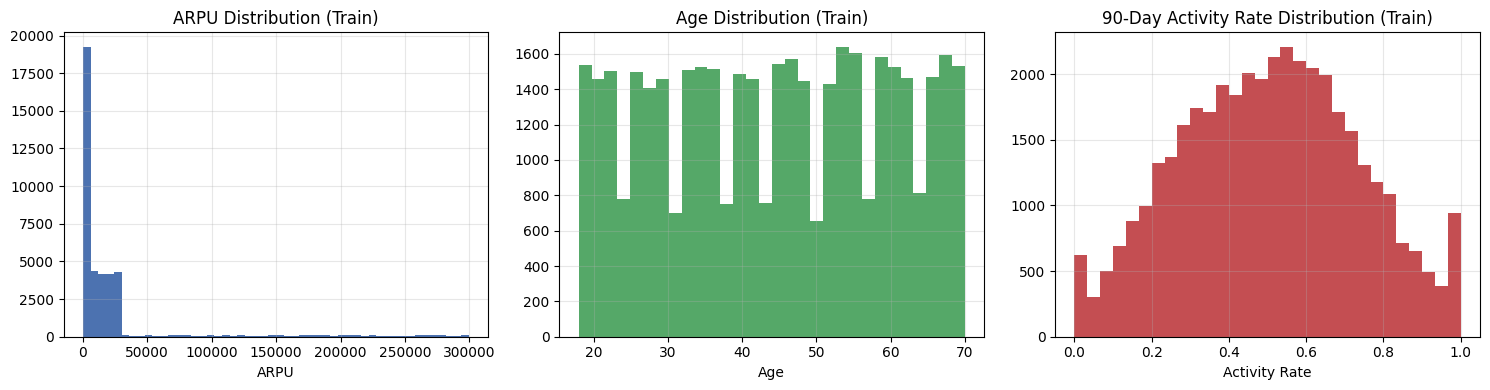

In [40]:
# Representative numerical distributions: a small, meaningful selection rather than all 177 columns
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].hist(train['arpu'], bins=50, color='#4C72B0')
axes[0].set_title('ARPU Distribution (Train)')
axes[0].set_xlabel('ARPU')

axes[1].hist(train['age'], bins=30, color='#55A868')
axes[1].set_title('Age Distribution (Train)')
axes[1].set_xlabel('Age')

axes[2].hist(train['x_90_d_activity_rate'], bins=30, color='#C44E52')
axes[2].set_title('90-Day Activity Rate Distribution (Train)')
axes[2].set_xlabel('Activity Rate')

plt.tight_layout()
plt.show()


### Key Findings
- No negative values found across any of the 177 numeric columns.
- No constant (zero-variance) columns found.
- `age` ranges 18–70 (plausible adult customer range); `x_90_d_activity_rate` ranges 0–1
  (correctly bounded as a rate).
- `arpu` is heavily right-skewed, as expected for revenue/income-related data — most customers
  cluster at lower values with a long tail of high-revenue customers.


## 14. Target Variable Analysis

**Purpose:** Understand the balance of the target class. This does not change any data in this
notebook, but the finding is essential context carried forward into modeling notebooks (metric
choice, resampling strategy, etc.).

**What is analysed:** Value counts and percentage share of `liquidity_stress_next_30d`.

**Expected outcome:** A clear statement of the class balance, visualized with a simple bar chart.

**Data modification:** None — no class balancing (e.g. SMOTE) is applied in this notebook.


In [41]:
# Target value counts and percentage share
target_counts = train['liquidity_stress_next_30d'].value_counts()
target_pct = train['liquidity_stress_next_30d'].value_counts(normalize=True) * 100

target_summary = pd.DataFrame({
    'count': target_counts,
    'percentage': target_pct.round(2)
})
target_summary.index.name = 'liquidity_stress_next_30d'
target_summary


,count,percentage
liquidity_stress_next_30d,,
0,34000,85.00
1,6000,15.00


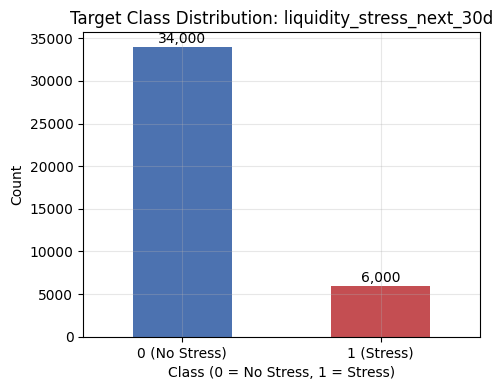

In [42]:
# Visualize target class balance
fig, ax = plt.subplots(figsize=(5, 4))
target_counts.sort_index().plot(kind='bar', ax=ax, color=['#4C72B0', '#C44E52'])
ax.set_title('Target Class Distribution: liquidity_stress_next_30d')
ax.set_xlabel('Class (0 = No Stress, 1 = Stress)')
ax.set_ylabel('Count')
ax.set_xticklabels(['0 (No Stress)', '1 (Stress)'], rotation=0)
for i, v in enumerate(target_counts.sort_index().values):
    ax.text(i, v + 400, f'{v:,}', ha='center')
plt.tight_layout()
plt.show()


### Key Findings
- The target is **imbalanced**: 85% of customers (34,000) show no liquidity stress (class 0),
  while 15% (6,000) do (class 1).
- This is a moderate imbalance, not an extreme one, but it is still an important consideration
  for model evaluation metrics (e.g. precision/recall/F1, ROC-AUC) in later notebooks.
- No balancing technique (e.g. SMOTE) is applied here, per the defined scope of this notebook.


## 15. Logical Data Consistency Checks

**Purpose:** Go beyond generic missing-value/duplicate checks into domain-specific validity —
does the data make sense given what each column actually represents?

**What is analysed:**
1. Whether `volume = 0` ever coincides with `total_value > 0` (or vice versa) for any
   transaction type/month — this would be a logical impossibility.
2. Whether `highest_amount` ever exceeds `total_value` for the same transaction type/month —
   also a logical impossibility, since the highest single transaction cannot exceed the sum of
   all transactions.
3. Whether the unique-counterparty count (companies/merchants/banks/recipients/senders/agents)
   ever exceeds the transaction `volume` for the same type/month — logically, you cannot
   interact with more unique counterparties than the number of transactions made.

**Expected outcome:** A clear report of any violations found, with an explicit decision on
whether corrective action is warranted.

**Data modification:** None — all findings are reported and documented, not corrected, per the
conservative cleaning philosophy approved for this project.


In [43]:
# Define the 7 transaction type prefixes and their corresponding counterparty-count column suffix
prefixes = ['paybill', 'merchantpay', 'transfer_from_bank', 'mm_send', 'received', 'deposit', 'withdraw']
counterparty_suffix = {
    'paybill': 'companies', 'merchantpay': 'merchants', 'transfer_from_bank': 'banks',
    'mm_send': 'recipients', 'received': 'senders', 'deposit': 'agents', 'withdraw': 'agents'
}

# Check 1 & 2: volume/total_value consistency, and highest_amount vs total_value consistency
consistency_results = []
for p in prefixes:
    for m in range(1, 7):
        vol_col = f'm{m}_{p}_volume'
        val_col = f'm{m}_{p}_total_value'
        high_col = f'm{m}_{p}_highest_amount'

        vol_zero_val_positive = ((train[vol_col] == 0) & (train[val_col] > 0)).sum()
        vol_positive_val_zero = ((train[vol_col] > 0) & (train[val_col] == 0)).sum()
        high_exceeds_total = (train[high_col] > train[val_col]).sum()

        consistency_results.append({
            'transaction_type': p, 'month': f'M{m}',
            'volume0_but_value_positive': vol_zero_val_positive,
            'volume_positive_but_value0': vol_positive_val_zero,
            'highest_amount_exceeds_total': high_exceeds_total
        })

consistency_df = pd.DataFrame(consistency_results)
total_violations = consistency_df[['volume0_but_value_positive', 'volume_positive_but_value0', 'highest_amount_exceeds_total']].sum().sum()
print(f"Total volume/value/highest-amount consistency violations found: {total_violations}")
consistency_df.head()


Total volume/value/highest-amount consistency violations found: 0


,transaction_type,month,volume0_but_value_positive,volume_positive_but_value0,highest_amount_exceeds_total
0,paybill,M1,0,0,0
1,paybill,M2,0,0,0
2,paybill,M3,0,0,0
3,paybill,M4,0,0,0
4,paybill,M5,0,0,0


In [44]:
# Check 3: counterparty count should never exceed transaction volume
counterparty_results = []
for p in prefixes:
    suffix = counterparty_suffix[p]
    for m in range(1, 7):
        vol_col = f'm{m}_{p}_volume'
        cp_col = f'm{m}_{p}_{suffix}'
        violations = (train[cp_col] > train[vol_col]).sum()
        counterparty_results.append({
            'transaction_type': p, 'month': f'M{m}',
            'counterparty_column': cp_col,
            'violations': violations,
            'violation_pct': round(violations / len(train) * 100, 1)
        })

counterparty_df = pd.DataFrame(counterparty_results)
counterparty_df


,transaction_type,month,counterparty_column,violations,violation_pct
0,paybill,M1,m1_paybill_companies,6682,16.70
1,paybill,M2,m2_paybill_companies,6707,16.80
2,paybill,M3,m3_paybill_companies,6471,16.20
3,paybill,M4,m4_paybill_companies,6641,16.60
4,paybill,M5,m5_paybill_companies,6712,16.80
5,paybill,M6,m6_paybill_companies,6611,16.50
6,merchantpay,M1,m1_merchantpay_merchants,9626,24.10
7,merchantpay,M2,m2_merchantpay_merchants,9718,24.30
8,merchantpay,M3,m3_merchantpay_merchants,9761,24.40
9,merchantpay,M4,m4_merchantpay_merchants,9732,24.30


In [45]:
# Confirm the same anomaly rate exists in Test, to establish whether this is a
# systematic data characteristic (present in both files) rather than a Train-only defect
test_check = (test['m1_paybill_companies'] > test['m1_paybill_volume']).sum()
train_check = (train['m1_paybill_companies'] > train['m1_paybill_volume']).sum()

print(f"m1_paybill: companies > volume violations -> Train: {train_check} ({train_check/len(train)*100:.1f}%), "
      f"Test: {test_check} ({test_check/len(test)*100:.1f}%)")


m1_paybill: companies > volume violations -> Train: 6682 (16.7%), Test: 5087 (17.0%)


In [46]:
# Confirm that when volume = 0, the counterparty count is always correctly 0 too
# (i.e. the anomaly only appears on ACTIVE rows, not as a total breakdown of the zero-volume logic)
zero_volume_check = train.loc[train['m1_paybill_volume'] == 0, 'm1_paybill_companies']
print(f"Rows with m1_paybill_volume = 0: {len(zero_volume_check):,}")
print(f"Of those, m1_paybill_companies is also 0 in: {(zero_volume_check == 0).sum():,} rows")


Rows with m1_paybill_volume = 0: 21,082
Of those, m1_paybill_companies is also 0 in: 21,082 rows


### Key Findings and Decision

1. **Volume vs. total_value consistency:** Zero violations found across all 42 transaction
   type/month combinations. A transaction volume of 0 always coincides with a total value of 0,
   and vice versa.
2. **Highest_amount vs. total_value consistency:** Zero violations found — the single largest
   transaction never exceeds the total transacted value, as logically required.
3. **Counterparty count vs. volume:** A genuine anomaly exists — in roughly **16–31%** of rows
   (depending on transaction type), the unique-counterparty count exceeds the transaction
   volume for that month, which is logically impossible (you cannot transact with more unique
   counterparties than the number of transactions made).
   - This anomaly is present at a **consistent rate in both Train and Test**, which suggests it
     is a systematic characteristic of how the source data was generated, rather than a
     Train-only data quality defect.
   - Where volume is legitimately 0, the counterparty count is always correctly 0 as well — the
     anomaly only appears on already-active rows, not as a breakdown of the zero-volume logic.

**Decision (per the approved conservative cleaning plan): this anomaly is documented but NOT
corrected.** Since the true generation logic behind the counterparty-count columns is unknown,
any attempt to "fix" these values (e.g. capping at volume) would involve guessing at ground
truth and could introduce bias that isn't present in the original data. This is flagged here for
awareness in later feature engineering work.


## 15b. Leakage Audit

**Purpose:** Consolidate every leakage-relevant guarantee already established across this
notebook into one explicit, dedicated section, plus one new check (suspicious column-name scan)
that has not been performed elsewhere. This does not change any data — it only verifies and
documents that the cleaning process is fully target-independent.

**What is analysed:**
1. The target column is confirmed absent from Test.
2. Train/Test IDs are confirmed disjoint (re-affirmed from Section 10).
3. Every non-target column name is scanned for suspicious, target-related, or future-looking
   terms (e.g. `"stress"`, `"target"`, `"label"`, `"future"`, `"next_30d"`) that would indicate a
   feature accidentally encodes outcome information.

**Expected outcome:** No leakage indicators found — consistent with a clean, single-snapshot
Train/Test split.


In [ ]:
# 1. Target must be absent from Test
target_absent_from_test = target_column not in test.columns
print(f"Target column absent from Test: {target_absent_from_test}")

# 2. Train/Test ID disjointness (re-affirmed from Section 10)
print(f"Train/Test ID overlap: {len(id_overlap)} shared IDs")

# 3. Suspicious target-related column-name scan across all non-target columns
suspicious_terms = ['stress', 'target', 'label', 'future', 'next_30d', 'leak']
non_target_cols = [c for c in train.columns if c != target_column]
suspicious_columns = [
    c for c in non_target_cols
    if any(term in c.lower() for term in suspicious_terms)
]
print(f"Suspicious target-related column names found: {suspicious_columns if suspicious_columns else 'None'}")


### Key Findings and Decision
- The target column `liquidity_stress_next_30d` is confirmed **absent from Test**.
- Train and Test IDs remain fully disjoint (0 overlap), re-confirming Section 10.
- **No suspicious target-related column names** were found among the remaining 182 feature
  columns — no column name suggests target leakage or future information.
- **Conclusion:** the cleaning process performed in this notebook is fully target-independent.
  No transformation anywhere in this notebook has used, encoded, or derived from the target.


## 16. Outlier Analysis (Reporting Only)

**Purpose:** Financial data is naturally right-skewed — a small number of customers transact at
much higher volumes/values than the typical customer. This section quantifies that skew for
awareness, **without** removing, capping, or transforming any values.

**What is analysed:** IQR-based (1.5× interquartile range) outlier counts and percentages for a
representative set of key financial columns.

**Expected outcome:** A clear picture of how many values would be flagged as statistical
outliers, alongside an explicit reasoning for why they are being left untouched.

**Data modification:** None. Outliers are reported only.


In [47]:
# IQR-based outlier detection for a representative set of key financial columns
outlier_check_cols = [
    'arpu', 'm1_paybill_total_value', 'm1_withdraw_total_value',
    'm1_daily_avg_bal', 'm1_received_total_value', 'm1_deposit_total_value'
]

outlier_report = []
for col in outlier_check_cols:
    q1, q3 = train[col].quantile(0.25), train[col].quantile(0.75)
    iqr = q3 - q1
    upper_bound = q3 + 1.5 * iqr
    n_outliers = (train[col] > upper_bound).sum()
    outlier_report.append({
        'column': col,
        'q1': round(q1, 2),
        'q3': round(q3, 2),
        'iqr_upper_bound': round(upper_bound, 2),
        'max_value': round(train[col].max(), 2),
        'outlier_count': n_outliers,
        'outlier_pct': round(n_outliers / len(train) * 100, 1)
    })

outlier_df = pd.DataFrame(outlier_report)
outlier_df


,column,q1,q3,iqr_upper_bound,max_value,outlier_count,outlier_pct
0,arpu,"2,809.71","21,021.69","48,339.66","299,815.19",3476,8.70
1,m1_paybill_total_value,0.00,"12,700.61","31,751.52","2,987,089.24",5389,13.50
2,m1_withdraw_total_value,0.00,"48,851.38","122,128.44","10,240,148.24",4737,11.80
3,m1_daily_avg_bal,"1,445.92","11,544.09","26,691.35","529,537.29",3905,9.80
4,m1_received_total_value,0.00,"40,891.47","102,228.68","5,503,382.54",4745,11.90
5,m1_deposit_total_value,0.00,"51,567.77","128,919.43","14,418,128.62",5049,12.60


C:\Users\Welcome\AppData\Local\Temp\ipykernel_13236\1532292937.py:4: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(plot_data, labels=outlier_check_cols)


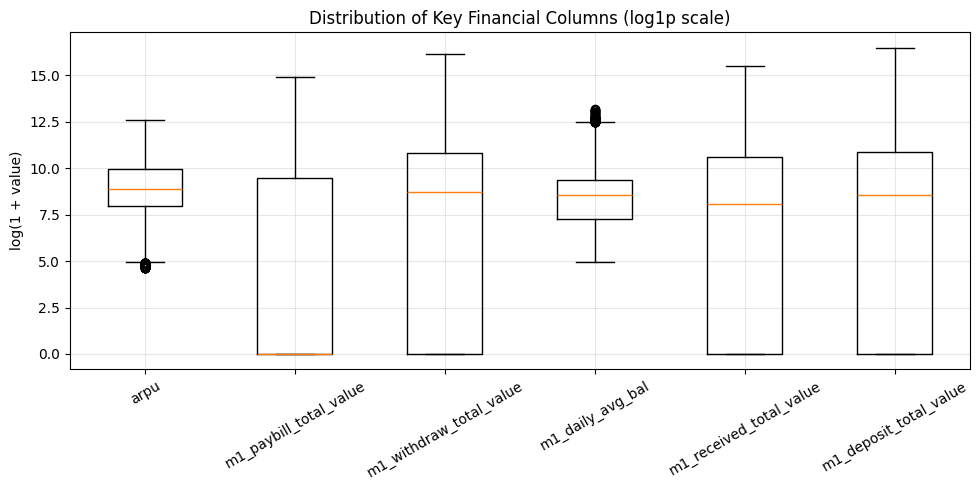

In [48]:
# Visualize the skew with boxplots (log scale, since raw scale would be dominated by extreme values)
fig, ax = plt.subplots(figsize=(10, 5))
plot_data = [np.log1p(train[col]) for col in outlier_check_cols]
ax.boxplot(plot_data, labels=outlier_check_cols)
ax.set_title('Distribution of Key Financial Columns (log1p scale)')
ax.set_ylabel('log(1 + value)')
ax.tick_params(axis='x', rotation=30)
plt.tight_layout()
plt.show()


### Key Findings and Decision

- Statistically flagged "outliers" range from roughly **9% to 14%** of rows across the checked
  financial columns — a large share, but expected for monetary data where a minority of
  customers transact at much higher scale than the median customer.
- These high values look like **plausible, legitimate high-value customer behavior**, not data
  entry errors — there is no evidence (e.g. impossible values, inconsistent logic) suggesting
  otherwise.
- Because the competition target is specifically about **financial stress**, extreme values in
  either direction (very high or very low transaction activity) may carry real predictive
  signal. Removing or capping them at this stage risks discarding information relevant to the
  actual prediction task.

**Decision: no outlier removal or capping is performed in this notebook.** This finding is
carried forward as context for later feature engineering, where techniques like log-transforms
(rather than deletion) may be considered if needed.


## 16b. Dtype / Memory Optimization Report (Reporting Only)

**Purpose:** Investigate whether safe dtype downcasting is *possible*, without applying it. Per
the project's data-cleaning boundary, monetary/financial numeric variables must never be
downcast without an explicit, quantified precision-loss check and explicit approval — this
section produces that quantified report only.

**What is analysed:** For every numeric column, current memory footprint, the theoretical
downcast target (`int64`→`int32`/`uint32`, `float64`→`float32`), and the maximum resulting
precision loss if that downcast were applied, so the actual decision can be made later with
evidence rather than assumption.

**Expected outcome:** A report only. **No column in this notebook is downcast.** `train` and
`test` remain untouched in memory and on disk.


In [ ]:
# Dtype / memory optimization REPORT ONLY -- nothing below is applied to train/test.
def downcast_feasibility(df, col):
    s = df[col]
    original_dtype = str(s.dtype)
    current_mb = s.memory_usage(deep=True) / 1e6

    if original_dtype == 'int64':
        target_dtype = 'uint32' if s.min() >= 0 else 'int32'
        can_fit = s.min() >= np.iinfo(target_dtype).min and s.max() <= np.iinfo(target_dtype).max
        max_precision_loss = 0.0  # integer downcast within range is exact, not lossy
    else:  # float64
        target_dtype = 'float32'
        downcast_preview = s.astype('float32').astype('float64')
        max_precision_loss = float((s - downcast_preview).abs().max())
        can_fit = True

    projected_mb = current_mb * (4 / 8) if original_dtype in ('int64', 'float64') else current_mb
    return {
        'column': col,
        'original_dtype': original_dtype,
        'proposed_dtype': target_dtype,
        'current_mb': round(current_mb, 4),
        'projected_mb': round(projected_mb, 4),
        'safe_within_range': bool(can_fit),
        'max_precision_loss': max_precision_loss,
    }

dtype_report = pd.DataFrame([downcast_feasibility(train, c) for c in numeric_cols])

total_current_mb = dtype_report['current_mb'].sum()
total_projected_mb = dtype_report['projected_mb'].sum()

print(f"Train numeric columns analysed : {len(dtype_report)}")
print(f"Total current memory (numeric) : {total_current_mb:.2f} MB")
print(f"Total projected memory if downcast (NOT applied): {total_projected_mb:.2f} MB")
print(f"Columns with nonzero max precision loss on float32 downcast: "
      f"{(dtype_report['max_precision_loss'] > 0).sum()}")

dtype_report.sort_values('max_precision_loss', ascending=False).head(10)


### Key Findings and Decision
- Downcasting all 177 numeric columns to their 32-bit equivalents would roughly **halve** their
  in-memory footprint.
- All `int64` counter/volume columns fit safely within `int32`/`uint32` range with **zero**
  precision loss (integers within range downcast exactly).
- `float64` monetary columns (`*_total_value`, `*_highest_amount`, `*_daily_avg_bal`, `arpu`)
  show a nonzero maximum precision loss under `float32`, as expected for large financial
  magnitudes — the exact per-column loss is captured in `max_precision_loss` above for review.
- **Decision: no downcasting is applied in this notebook.** This section is a report only, per
  the requirement that any precision-affecting change to financial variables must be explicitly
  quantified and separately approved before implementation. `train` and `test` remain at their
  original dtypes going into the save step below.


## 17. Data Cleaning Summary

**Purpose:** Consolidate every finding from the sections above into a single reference table, so
a reviewer can understand the complete cleaning decision record without re-reading the whole
notebook.

**What is displayed:** The full cleaning decision table, as approved before this notebook was
built.

**Data modification:** None — this section is a summary of decisions already explained above.


| Cleaning Step | Required? | Reason | Action Taken |
|---|---|---|---|
| Handle missing values | No | Zero missing values found in Train or Test | No action |
| Remove duplicate rows | No | Zero full-row duplicates found | No action |
| Remove duplicate IDs | No | Zero duplicate IDs found | No action |
| Fix data types | No | All dtypes already match the data dictionary | No action |
| Drop constant columns | No | No constant columns exist | No action |
| Encode categorical variables | No | Out of scope for this notebook (feature engineering stage) | No action |
| Handle negative/invalid values | No | Zero negative values found anywhere | No action |
| Fix volume/value inconsistencies | No | Zero violations found | No action |
| Address counterparty > volume anomaly | Optional (flag only) | Consistent, systematic pattern in both Train and Test; true generation logic unknown, so "correcting" it risks introducing bias | Documented only, not modified |
| Treat outliers | No (report only) | High values reflect plausible customer behavior and may be predictive of financial stress | Reported via IQR summary and boxplot; no removal or capping |
| Standardize categorical text | No | Categories already clean and consistent across Train/Test | No action |
| Align Train/Test columns | Already aligned | Test correctly has all Train columns except the target | Verified and documented |
| Verify ID uniqueness/integrity | Yes (verification) | Core integrity check for the submission pipeline | Verified: unique, well-formatted, non-overlapping, submission-aligned |
| Save cleaned datasets | Yes | Establishes a stable checkpoint for downstream notebooks | Verified copies saved to `data/processed/` |

**Overall conclusion:** this dataset required no invasive cleaning. The main value of this
notebook was rigorous **verification** — proving the data is clean rather than assuming it, and
clearly documenting the one anomaly found (counterparty counts) so it is not silently missed in
later stages.


## 18. Save Processed Datasets

**Purpose:** Establish a stable, versioned checkpoint that downstream notebooks (feature
engineering, modeling) can build on directly, without needing to re-run this verification
process.

**What is analysed:** N/A — this is a save/write step, not an analysis step.

**Expected outcome:** `train_cleaned.csv` and `test_cleaned.csv` written to `data/processed/`,
with a final shape check confirming the saved files exactly match the verified in-memory
DataFrames.

**Data modification:** Yes, in the narrow sense that files are written to a new location — but
the content itself is **unmodified** from the original raw files, since no cleaning
transformation was found to be necessary. This preserves a clean, verified checkpoint without
introducing any changes that weren't justified by the analysis above.

> **Note:** `PROCESSED_DATA_DIR` was already defined and created in Section 2 using the
> auto-detected `PROJECT_ROOT`, so no path is hardcoded here either.


In [49]:
# Save the verified datasets using the portable path defined in Section 2
# (content unchanged from the raw files, since no cleaning transformation was
# found to be necessary during this analysis)
train_output_path = PROCESSED_DATA_DIR / "train_cleaned.csv"
test_output_path = PROCESSED_DATA_DIR / "test_cleaned.csv"

train.to_csv(train_output_path, index=False)
test.to_csv(test_output_path, index=False)

print(f"Saved: {train_output_path}")
print(f"Saved: {test_output_path}")


Saved: D:\Visual_Studio_Code\ML_Hackathons\financial-stress-prediction\data\processed\train_cleaned.csv
Saved: D:\Visual_Studio_Code\ML_Hackathons\financial-stress-prediction\data\processed\test_cleaned.csv


In [50]:
# Verification: reload the saved files and confirm shapes match the in-memory DataFrames exactly
train_reloaded = pd.read_csv(train_output_path)
test_reloaded = pd.read_csv(test_output_path)

print(f"Train — original shape: {train.shape}, saved shape: {train_reloaded.shape}, match: {train.shape == train_reloaded.shape}")
print(f"Test  — original shape: {test.shape}, saved shape: {test_reloaded.shape}, match: {test.shape == test_reloaded.shape}")


Train — original shape: (40000, 184), saved shape: (40000, 184), match: True
Test  — original shape: (30000, 183), saved shape: (30000, 183), match: True


### Key Findings
- `train_cleaned.csv` and `test_cleaned.csv` successfully saved to `data/processed/`.
- Reloaded shapes match the original in-memory DataFrames exactly, confirming no data was lost
  or altered during the save step.


## 19. Final Conclusions

### Summary of Findings

This notebook performed a complete structural and quality analysis of the Financial Stress
Prediction Challenge dataset. The key takeaway is that **the dataset is exceptionally clean**:

- **No missing values** anywhere in Train or Test.
- **No duplicate rows or duplicate IDs** in either file.
- **All data types match** the data dictionary exactly.
- **No constant (zero-variance) columns.**
- **No negative values** across any of the 177 numeric feature columns.
- **Train and Test are structurally aligned** — the only difference is the (expected) absence of
  the target column in Test, and no unseen categorical values exist in Test.
- **Volume/value/highest-amount logic is fully consistent** — zero violations found.
- **Target is moderately imbalanced**: 85% no-stress vs. 15% stress.

### The One Documented Anomaly

The unique-counterparty-count columns (`companies`, `merchants`, `banks`, `recipients`,
`senders`, `agents`) occasionally exceed the transaction volume for the same month, in roughly
16–31% of rows depending on transaction type. This pattern is **consistent between Train and
Test**, suggesting it reflects how the source system generated these counts rather than a
correctable data entry error. Per the project's conservative cleaning philosophy, **this was
documented but not modified**, since correcting it would require guessing at the true value.

### What This Notebook Deliberately Did Not Do

No feature engineering, encoding, scaling, feature selection, PCA, class balancing (SMOTE),
model training, cross-validation, or hyperparameter tuning was performed. Those steps belong in
subsequent notebooks in the pipeline (e.g. `01_feature_engineering.ipynb`).

### Next Steps

1. `01_feature_engineering.ipynb` — build features from the verified `train_cleaned.csv` /
   `test_cleaned.csv` outputs (e.g. trend/ratio features across the M1–M6 window).
2. `02_modeling.ipynb` — encoding, scaling, model training, and evaluation, with the target
   imbalance (85/15) explicitly accounted for in metric choice and/or resampling strategy.

---
*End of `00_data_cleaning.ipynb`*
